<a href="https://colab.research.google.com/github/J-R4M/machine-learning/blob/main/hw-3/Homework_3_4105.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 3

## Setup

### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import SGDClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
    confusion_matrix,
    ConfusionMatrixDisplay
)

### Helper Functions

## Problem 1

### Load Diabetes Dataset

In [6]:
from google.colab import drive
drive.mount('/content/drive')

data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/diabetes.csv')

print("# of samples: ", len(data))
print("Columns: ", list(data.columns))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
# of samples:  768
Columns:  ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


### Inspect Dataset

In [7]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nClass distribution:")
print(df["Outcome"].value_counts())

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (768, 9)

Column names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Class distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


### Checking Invalid Zeros

In [8]:
zero_check_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

print("Zero values in medical measurements:")

for column in zero_check_columns:
    print(f"{column}: {(df[column] == 0).sum()}")

Zero values in medical measurements:
Glucose: 5
BloodPressure: 35
SkinThickness: 227
Insulin: 374
BMI: 11


### Select Input/Output Variables

In [10]:
x = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("Input shape:", X.shape)
print("Output shape:", y.shape)

Input shape: (768, 8)
Output shape: (768,)


### 80/20 Training/Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))

Training samples: 614
Test samples: 154

Training class distribution:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Test class distribution:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


### Handle Missing Values

In [19]:
missing_value_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

X_train = X_train.copy()
X_test = X_test.copy()

X_train[missing_value_columns] = X_train[missing_value_columns].replace(0, np.nan)
X_test[missing_value_columns] = X_test[missing_value_columns].replace(0, np.nan)

imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)



### Standardize Input Data

In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print("Mean after standardization:")
print(np.round(X_train_scaled.mean(axis=0), 3))

print("\nStandard deviation after standardization:")
print(np.round(X_train_scaled.std(axis=0), 3))

Mean after standardization:
[-0. -0.  0. -0. -0.  0. -0. -0.]

Standard deviation after standardization:
[1. 1. 1. 1. 1. 1. 1. 1.]


### Logistic Regression Training

In [22]:
# Number of training iterations
iterations = 500

# Logistic regression trained using stochastic gradient descent
model = SGDClassifier(
    loss="log_loss",
    penalty=None,
    learning_rate="constant",
    eta0=0.001,
    random_state=42
)

# Store training history
training_loss = []
training_accuracy = []

classes = np.array([0, 1])

for i in range(iterations):

    # Perform one training iteration
    model.partial_fit(
        X_train_scaled,
        y_train,
        classes=classes
    )

    # Predicted probabilities and classifications
    y_train_probability = model.predict_proba(X_train_scaled)
    y_train_prediction = model.predict(X_train_scaled)

    # Calculate loss
    loss = log_loss(
        y_train,
        y_train_probability
    )

    # Calculate classification accuracy
    accuracy = accuracy_score(
        y_train,
        y_train_prediction
    )

    training_loss.append(loss)
    training_accuracy.append(accuracy)

print("Training complete.")
print("Final training loss:", round(training_loss[-1], 4))
print("Final training accuracy:", round(training_accuracy[-1], 4))

Training complete.
Final training loss: 0.4531
Final training accuracy: 0.7948


### Training Loss

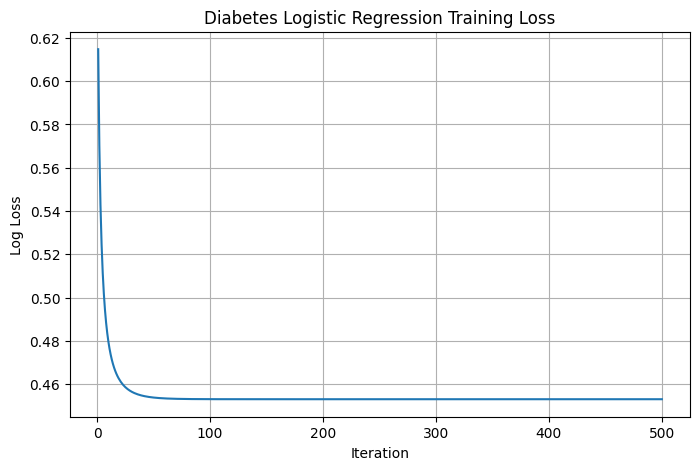

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, iterations + 1),
    training_loss
)

plt.xlabel("Iteration")
plt.ylabel("Log Loss")
plt.title("Diabetes Logistic Regression Training Loss")
plt.grid(True)

plt.show()

### Training Accuracy

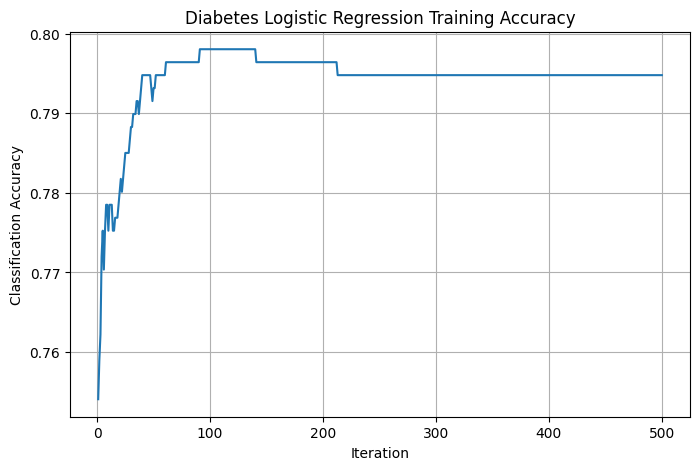

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, iterations + 1),
    training_accuracy
)

plt.xlabel("Iteration")
plt.ylabel("Classification Accuracy")
plt.title("Diabetes Logistic Regression Training Accuracy")
plt.grid(True)

plt.show()

### Classification Results

In [25]:
# Predict diabetes classifications for the test set
y_test_prediction = model.predict(X_test_scaled)

# Calculate evaluation metrics
test_accuracy = accuracy_score(
    y_test,
    y_test_prediction
)

test_precision = precision_score(
    y_test,
    y_test_prediction
)

test_recall = recall_score(
    y_test,
    y_test_prediction
)

test_f1 = f1_score(
    y_test,
    y_test_prediction
)

print("Test Results")
print("-------------------------")
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1 Score:  {test_f1:.4f}")

Test Results
-------------------------
Accuracy:  0.7013
Precision: 0.5870
Recall:    0.5000
F1 Score:  0.5400


### Confusion Matrix

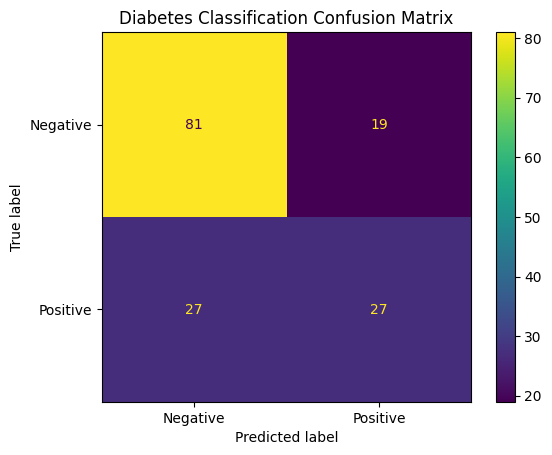

In [26]:
cm = confusion_matrix(
    y_test,
    y_test_prediction
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

display.plot()

plt.title("Diabetes Classification Confusion Matrix")
plt.show()

##Problem 2a


###Load Cancer Dataset


In [27]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

X_cancer = pd.DataFrame(
    cancer.data,
    columns=cancer.feature_names
)

# Convert target so malignant = 1 and benign = 0
y_cancer = pd.Series(
    (cancer.target == 0).astype(int),
    name="Malignant"
)

X_cancer.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


###Inspect Dataset


In [29]:
print("Dataset shape:", X_cancer.shape)

print("\nNumber of input features:")
print(X_cancer.shape[1])

print("\nTarget distribution:")
print(y_cancer.value_counts())

print("\nTarget labels:")
print("0 = Benign")
print("1 = Malignant")

Dataset shape: (569, 30)

Number of input features:
30

Target distribution:
Malignant
0    357
1    212
Name: count, dtype: int64

Target labels:
0 = Benign
1 = Malignant


###Select Input/Output Variables


In [31]:
X = X_cancer
y = y_cancer

print("Input shape:", X.shape)
print("Output shape:", y.shape)

Input shape: (569, 30)
Output shape: (569,)


###80/20 Training/Test Split


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

Training samples: 455
Test samples: 114

Training class distribution:
Malignant
0    285
1    170
Name: count, dtype: int64

Test class distribution:
Malignant
0    72
1    42
Name: count, dtype: int64


###Standardize Input Data


In [33]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

###Logistic Regression Training


In [37]:
iterations = 500

model_2a = SGDClassifier(
    loss="log_loss",
    penalty=None,
    learning_rate="constant",
    eta0=0.001,
    random_state=42
)

training_loss_2a = []
training_accuracy_2a = []

classes = np.array([0, 1])

for i in range(iterations):

    model_2a.partial_fit(
        X_train_scaled,
        y_train,
        classes=classes
    )

    y_train_probability = model_2a.predict_proba(
        X_train_scaled
    )

    y_train_prediction = model_2a.predict(
        X_train_scaled
    )

    loss = log_loss(
        y_train,
        y_train_probability
    )

    accuracy = accuracy_score(
        y_train,
        y_train_prediction
    )

    training_loss_2a.append(loss)
    training_accuracy_2a.append(accuracy)

print("Training complete.")
print(
    "Final training loss:",
    round(training_loss_2a[-1], 4)
)
print(
    "Final training accuracy:",
    round(training_accuracy_2a[-1], 4)
)

Training complete.
Final training loss: 0.0527
Final training accuracy: 0.989


###Training Loss


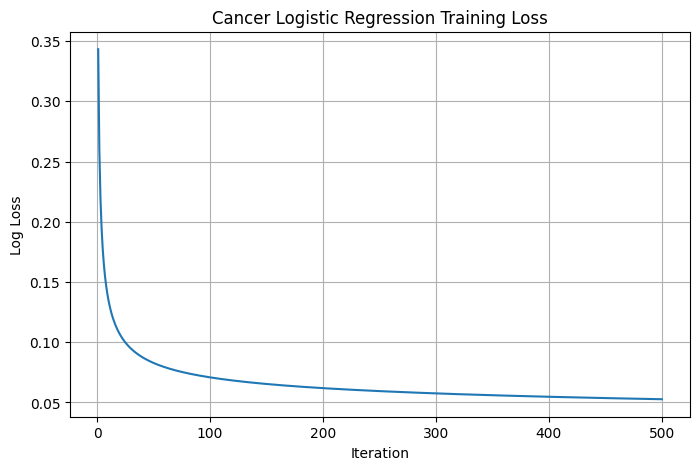

In [36]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, iterations + 1),
    training_loss_2a
)

plt.xlabel("Iteration")
plt.ylabel("Log Loss")
plt.title("Cancer Logistic Regression Training Loss")
plt.grid(True)

plt.show()

###Training Accuracy


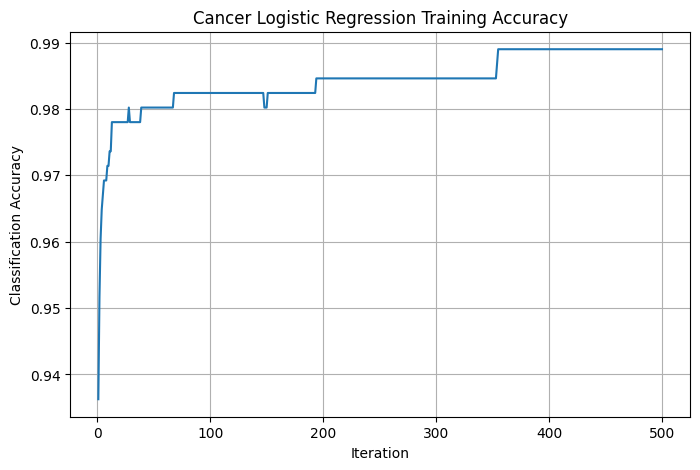

In [38]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, iterations + 1),
    training_accuracy_2a
)

plt.xlabel("Iteration")
plt.ylabel("Classification Accuracy")
plt.title("Cancer Logistic Regression Training Accuracy")
plt.grid(True)

plt.show()

###Classification Results


In [39]:
y_test_prediction_2a = model_2a.predict(
    X_test_scaled
)

accuracy_2a = accuracy_score(
    y_test,
    y_test_prediction_2a
)

precision_2a = precision_score(
    y_test,
    y_test_prediction_2a
)

recall_2a = recall_score(
    y_test,
    y_test_prediction_2a
)

f1_2a = f1_score(
    y_test,
    y_test_prediction_2a
)

print("Problem 2a Test Results")
print("-------------------------")
print(f"Accuracy:  {accuracy_2a:.4f}")
print(f"Precision: {precision_2a:.4f}")
print(f"Recall:    {recall_2a:.4f}")
print(f"F1 Score:  {f1_2a:.4f}")

Problem 2a Test Results
-------------------------
Accuracy:  0.9737
Precision: 0.9756
Recall:    0.9524
F1 Score:  0.9639


###Confusion Matrix


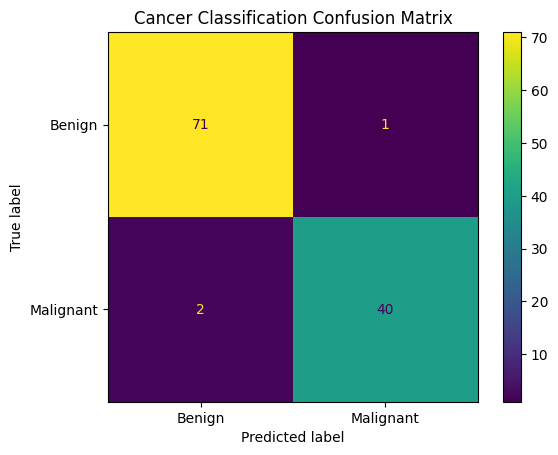

In [40]:
cm_2a = confusion_matrix(
    y_test,
    y_test_prediction_2a
)

display_2a = ConfusionMatrixDisplay(
    confusion_matrix=cm_2a,
    display_labels=["Benign", "Malignant"]
)

display_2a.plot()

plt.title(
    "Cancer Classification Confusion Matrix"
)

plt.show()

## Problem 2b

### Add Weight Penalty

In [41]:
# L2 regularization strength
alpha = 0.01

print("Regularization type: L2")
print("Regularization strength (alpha):", alpha)

Regularization type: L2
Regularization strength (alpha): 0.01


### Regularized Logistic Regression Training

In [42]:
iterations = 500

model_2b = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha=alpha,
    learning_rate="constant",
    eta0=0.001,
    random_state=42
)

training_loss_2b = []
training_accuracy_2b = []

classes = np.array([0, 1])

for i in range(iterations):

    model_2b.partial_fit(
        X_train_scaled,
        y_train,
        classes=classes
    )

    y_train_probability = model_2b.predict_proba(
        X_train_scaled
    )

    y_train_prediction = model_2b.predict(
        X_train_scaled
    )

    # Logistic loss
    logistic_loss = log_loss(
        y_train,
        y_train_probability
    )

    # L2 weight penalty
    penalty_loss = (
        alpha / 2
    ) * np.sum(model_2b.coef_ ** 2)

    # Total regularized loss
    total_loss = logistic_loss + penalty_loss

    accuracy = accuracy_score(
        y_train,
        y_train_prediction
    )

    training_loss_2b.append(total_loss)
    training_accuracy_2b.append(accuracy)

print("Training complete.")
print(
    "Final regularized training loss:",
    round(training_loss_2b[-1], 4)
)

print(
    "Final training accuracy:",
    round(training_accuracy_2b[-1], 4)
)

Training complete.
Final regularized training loss: 0.1001
Final training accuracy: 0.9802


### Training Loss

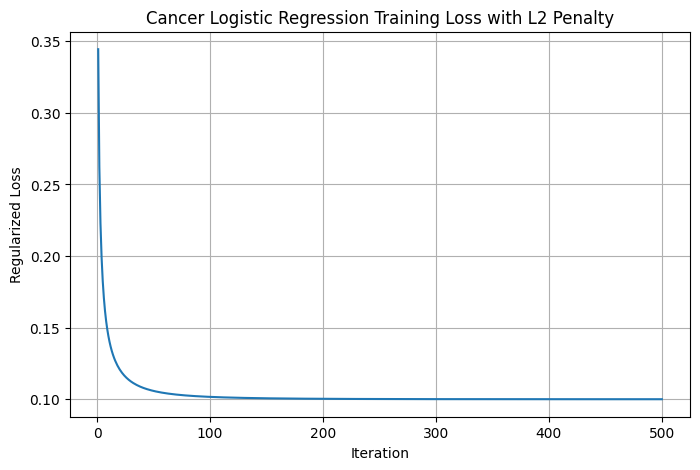

In [43]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, iterations + 1),
    training_loss_2b
)

plt.xlabel("Iteration")
plt.ylabel("Regularized Loss")
plt.title(
    "Cancer Logistic Regression Training Loss with L2 Penalty"
)
plt.grid(True)

plt.show()

### Training Accuracy

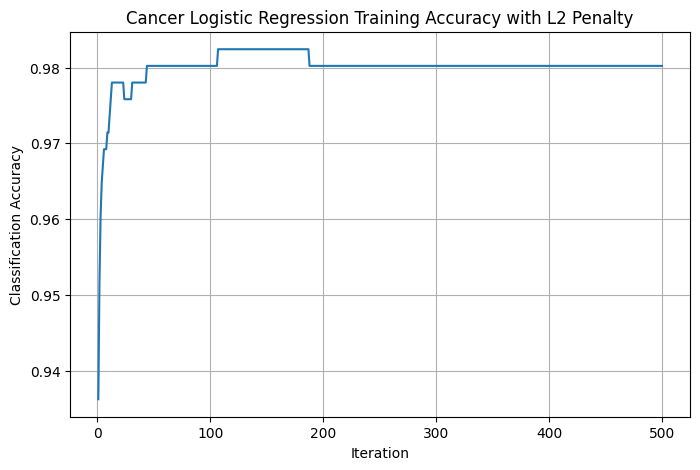

In [44]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, iterations + 1),
    training_accuracy_2b
)

plt.xlabel("Iteration")
plt.ylabel("Classification Accuracy")
plt.title(
    "Cancer Logistic Regression Training Accuracy with L2 Penalty"
)
plt.grid(True)

plt.show()

### Classification Results

In [45]:
y_test_prediction_2b = model_2b.predict(
    X_test_scaled
)

accuracy_2b = accuracy_score(
    y_test,
    y_test_prediction_2b
)

precision_2b = precision_score(
    y_test,
    y_test_prediction_2b
)

recall_2b = recall_score(
    y_test,
    y_test_prediction_2b
)

f1_2b = f1_score(
    y_test,
    y_test_prediction_2b
)

print("Problem 2b Test Results")
print("-------------------------")
print(f"Accuracy:  {accuracy_2b:.4f}")
print(f"Precision: {precision_2b:.4f}")
print(f"Recall:    {recall_2b:.4f}")
print(f"F1 Score:  {f1_2b:.4f}")

Problem 2b Test Results
-------------------------
Accuracy:  0.9825
Precision: 1.0000
Recall:    0.9524
F1 Score:  0.9756


### Confusion Matrix

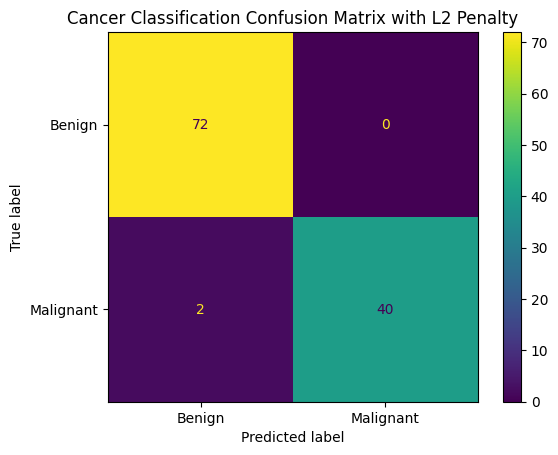

In [52]:
cm_2b = confusion_matrix(
    y_test,
    y_test_prediction_2b
)

display_2b = ConfusionMatrixDisplay(
    confusion_matrix=cm_2b,
    display_labels=["Benign", "Malignant"]
)

display_2b.plot()

plt.title(
    "Cancer Classification Confusion Matrix with L2 Penalty"
)

plt.show()

### Comparison with 2a

In [50]:
comparison = pd.DataFrame({
    "Model": [
        "Problem 2a - No Penalty",
        "Problem 2b - L2 Penalty"
    ],

    "Accuracy": [
        accuracy_2a,
        accuracy_2b
    ],

    "Precision": [
        precision_2a,
        precision_2b
    ],

    "Recall": [
        recall_2a,
        recall_2b
    ],

    "F1 Score": [
        f1_2a,
        f1_2b
    ]
})

comparison


,Model,Accuracy,Precision,Recall,F1 Score
0,Problem 2a - No Penalty,0.973684,0.97561,0.952381,0.963855
1,Problem 2b - L2 Penalty,0.982456,1.00000,0.952381,0.975610


In [51]:
weight_norm_2a = np.linalg.norm(
    model_2a.coef_
)

weight_norm_2b = np.linalg.norm(
    model_2b.coef_
)

print(
    "Weight magnitude without penalty:",
    round(weight_norm_2a, 4)
)

print(
    "Weight magnitude with L2 penalty:",
    round(weight_norm_2b, 4)
)

Weight magnitude without penalty: 3.9766
Weight magnitude with L2 penalty: 2.3272
